In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df= pd.read_csv("netflix_titles.csv")

In [24]:
df.shape

(8807, 12)

In [25]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [26]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [27]:
df.duplicated().sum()

np.int64(0)

Step 1 — Load & Inspect the Data(Summary)

1. On analyzing the Netflix dataset, we can see that it contains 8,807 rows and 12 columns.

2. The dataset contains information about Netflix movies and TV shows which includes attributes such as show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in and description.

3. Most of the columns in the dataset are of object datatype, while only the release_year column is of numeric (int) datatype.

4. We can observe that some columns contain missing values. Among them, the director column has the highest number of missing values, with around 2,634 missing entries out of 8,807 records.

5. On further observation, no duplicate records were found in the dataset, which means all the entries in the dataset are unique.


----------------------------------------------------------------------------------------------------------------------------------------------------------------

.

In [28]:
df.drop("director",axis=1,inplace=True)

Step 2- 1. Director Column Dropped.

1. The director column was dropped from the dataset because it contained 2,634 missing values out of 8,807 records, which is approximately **30%** of the total data [(2634/8807) × 100 = 29.9% ≈ 30%].
2. The director names are generally unique for different movies and TV shows, therefore filling the missing values would not contribute meaningfully to the analysis.
3. The missing values also cannot be reasonably filled using mean or median since the column contains text data. Although mode can be used, the most frequent director would still represent only a small portion of the dataset and would not be suitable for replacing such a large number of missing values.
4. Therefore, dropping the column was considered the most appropriate decision.


In [29]:
df["cast"]=df["cast"].fillna("Unknown")

Step 2- 2. Cast column.

1. The missing values in the cast column were replaced with "Unknown" because the column contained 825 missing values out of 8,807 records, which is approximately 9.4% of the dataset.
2. Dropping the entire column would not be beneficial as more than 90% of the records still contain useful cast information that can be used for further analysis.
3. Filling the missing values using mode was not considered appropriate because the most frequent cast combination would represent only a small portion of the dataset and would not accurately represent the missing entries.
4. Therefore, replacing the missing values with "Unknown" was considered a more suitable approach.


In [30]:
df["country"]=df["country"].fillna("Unknown")

Step 2- 3.Country column.

1. A similar approach as the cast column was applied to the country column, as it contains 831 missing values out of 8,807 records while the majority of the data is still intact.
2. The country column is important because it can be used for analyzing the global distribution of movies and TV shows available on Netflix.
3. Dropping the entire column would result in the loss of valuable information, while filling the missing values with random country names could lead to misinformation and inaccurate analysis.
4. Therefore, the missing values were replaced with "Unknown" to preserve the dataset while clearly indicating unavailable information.


In [31]:
df["rating"]=df['rating'].fillna(df['rating'].mode()[0])

Step 2- 4.Rating column

1. In the rating column, we only have 4 missing values, so instead of dropping the column or rows, we will fill them.
2. There are many methods available for handling missing values such as mean, median, mode, forward fill, and backward fill. The most suitable method for this column is mode, where the most frequent rating will be used to fill the missing values.
3. Mean and median cannot be used because the rating column contains object (categorical) data.
4. Forward fill and backward fill are also not appropriate because they fill the missing values according to the neighbouring records, which may not represent the actual rating and can lead to inaccurate results.


In [32]:
df["duration"]=df["duration"].fillna("Unknown")

Step 2- 5.Duration column

1. The duration column contains only 3 missing values out of 8,807 records, therefore dropping the entire column would be unnecessary as the column still contains useful information for further analysis.
2. There are several methods available for handling missing values such as mode, forward fill, and backward fill.
3. Forward fill and backward fill were not considered appropriate because they assign values based on neighbouring records, which may not represent the actual duration of the content.
4. Mode is not considered suitable because the duration column contains a variety of values such as movie durations and TV show seasons, and the most frequent duration may not accurately represent the missing entries.
5. Therefore, the missing values were replaced with "Unknown" to preserve the dataset while clearly indicating unavailable information.


In [33]:
df["date_added"]=df["date_added"].fillna("Unknown")

Step 2- 6.Date added column

1. There are 10 missing values in the date_added column. There are two possible approaches for handling these missing values.
2. **Approach 1:** Filling the missing values with "Unknown". Using methods such as mode, forward fill, or backward fill may introduce inaccurate dates into the dataset and affect the consistency of the data. Therefore, replacing the missing values with "Unknown" helps maintain data integrity while clearly indicating that the information is unavailable.

3. **Approach 2:** Deleting the 10 rows containing the missing values. These 10 records contribute only about 0.11% of the total dataset [(10/8807) × 100], so removing them would have a very small impact on the overall analysis. However, deleting these rows may also result in the loss of valuable information present in the other columns.

4. Therefore, Approach 1 was selected and the missing values were replaced with "Unknown" to preserve all records while maintaining consistency in the dataset.


In [34]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


Step 2- Final Summary

As we can see, all the missing values have been handled properly while maintaining the data integrity and consistency of the dataset. Appropriate methods were selected for each column based on the type of data and the number of missing values. Therefore, the dataset is now clean and ready for further analysis and visualization.


--------------------------------------------------------------------------------------------------------------------------------------------------------------

**Step 3 — Exploratory Data Analysis**

Q.1- How many "Movies" and "TV Shows" are there on Netflix?

In [35]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


Answer:- There are **6,131** Movies and **2,676** TV Shows available on Netflix. Movies make up the majority of the content available on the platform.

Q.2-Which countries have the highest number of Netflix titles?

In [36]:
df.groupby("country")["title"].count().sort_values(ascending=False).head(10)

,title
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


Answer:- The United States have the highest Netflix titles with **2,818** titles followed by India having **972** titles and then the United Kingdom having **419** titles.

  The "Unknown" category appears in the 3rd place because missing values in the country column were replaced with "Unknown" during the data cleaning process.

Q.3-How many titles were released after 2020?

In [37]:
df[df["release_year"]>2020]["title"].count()

np.int64(592)

Answer: A total of **592** Movies and TV Shows were released after 2020

Q.4-How many different rating categories are present in the dataset?

In [38]:
df['rating'].nunique()

17

Answer: There are **17** unique rating categories in the dataset containing 8,807 Netflix titles.

Q.5-What are the statistical details of the release year column?

In [39]:
df['release_year'].describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Answer: From the statistical summary of the release_year column, we can observe that:

1. The dataset contains **8,807** Netflix titles.
2. The average release year of titles in the dataset is approximately **2014**.
3. The earliest title in the dataset was released in **1925**.
4. The latest title in the dataset was released in **2021**.
5. 25% of the titles were released in or before **2013**.
6. 50% of the titles (median) were released in or before **2017**.
7. 75% of the titles were released in or before **2019**.
8. The standard deviation is around **8.82** years, which shows that the release years are not spread very far from the average year (2014). This means most of the titles were released within a similar time period and there is not a very large variation in the release years.

 Step 4 — Visualizations (Minimum 6 Charts)

Visualization 1: Top 10 Countries by Number of Netflix Titles(Bar Chart)

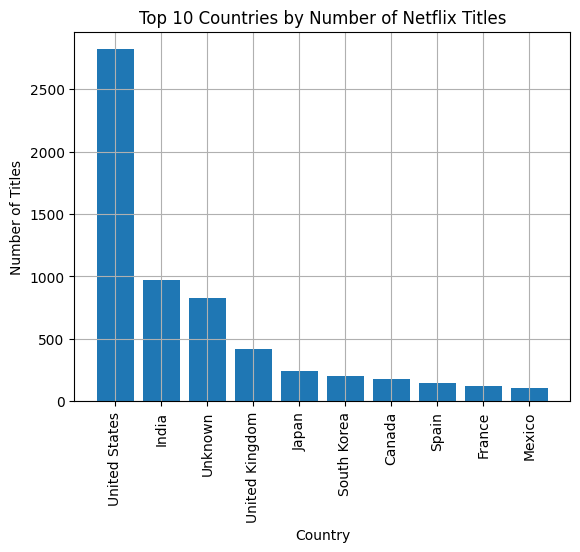

In [40]:
top10=df["country"].value_counts().head(10)
plt.bar(top10.index,top10.values)
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.grid()
plt.ylabel("Number of Titles")
plt.title("Top 10 Countries by Number of Netflix Titles")
plt.show()

Visualization 2: Netflix Titles Released by Year(Line Chart)

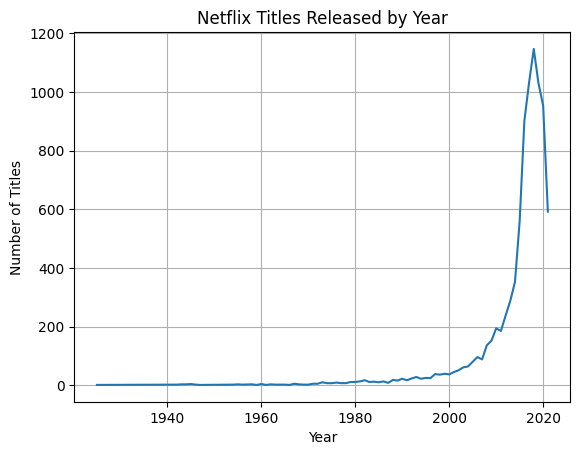

In [41]:
x=df["release_year"].value_counts().sort_index().index
y=df["release_year"].value_counts().sort_index().values
plt.plot(x,y)
plt.grid()
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.title("Netflix Titles Released by Year")
plt.show()



Visualization 3: Distribution of Release Years(Histogram)

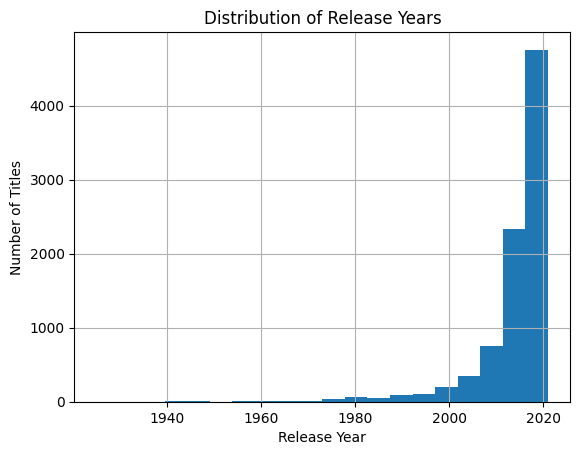

In [42]:
plt.hist(df["release_year"],bins=20)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.title("Distribution of Release Years")
plt.grid()
plt.show()

Visualization 4: Movies vs TV Shows Distribution(Pie Chart)

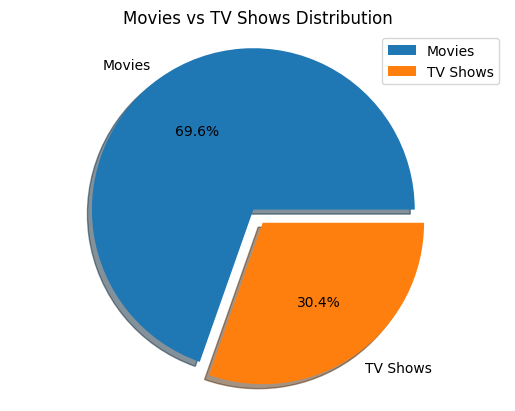

In [66]:

movies = df[df['type'] == 'Movie']["type"].count()
tv_shows = df[df['type'] == 'TV Show']["type"].count()
plt.pie([movies,tv_shows],labels=['Movies','TV Shows'],autopct='%1.1f%%',explode=[0,0.1],shadow=True)
plt.title('Movies vs TV Shows Distribution')
plt.legend(["Movies","TV Shows"])
plt.axis("equal")
plt.show()

Visualization 5: Correlation Between Numeric Variables(Heat Map)

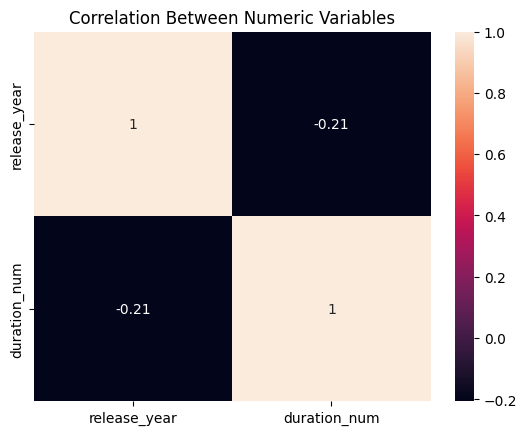

In [45]:
movie_df=df[df["type"]=="Movie"].copy()
movie_df = movie_df[movie_df["duration"]!="Unknown"]
movie_df["duration_num"]=movie_df["duration"].str.replace("min","").astype(int)
sns.heatmap(movie_df[["release_year","duration_num"]].corr(),annot=True)
plt.title("Correlation Between Numeric Variables")
plt.show()

Visualization 6: Distribution of Release Years(Box Plot)

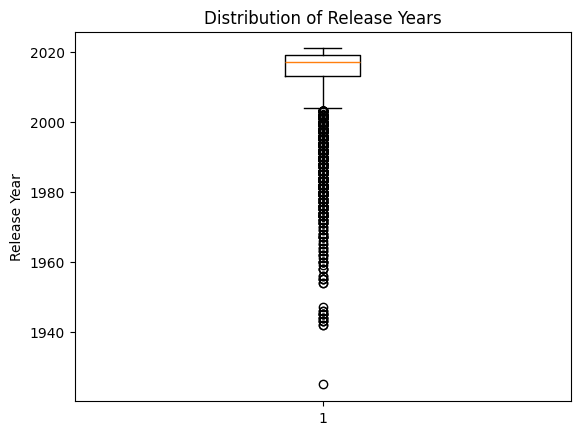

In [69]:
plt.boxplot(df["release_year"])
plt.ylabel("Release Year")
plt.title("Distribution of Release Years")
plt.show()

Visualization 7: Relationship Between Release Year and Duration(Scatter Plot)

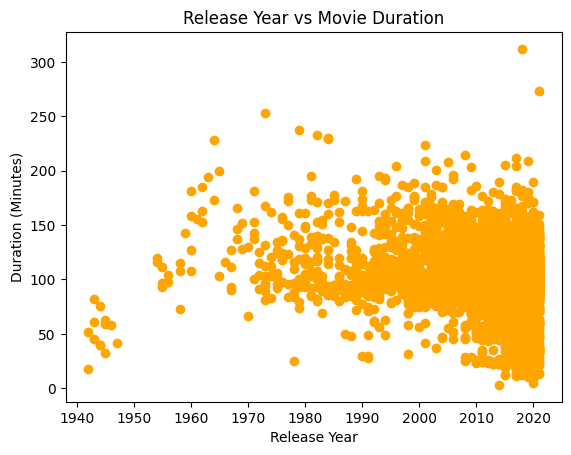

In [52]:
movie_df = df[df["type"]=="Movie"].copy()
movie_df = movie_df[movie_df["duration"]!="Unknown"]
movie_df["duration_num"] = movie_df["duration"].str.replace(" min","").astype(int)

plt.scatter(movie_df["release_year"], movie_df["duration_num"],color="orange")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")
plt.title("Release Year vs Movie Duration")
plt.show()

Visualization 8: Relationship Between Release Year and Duration(Bubble Plot)

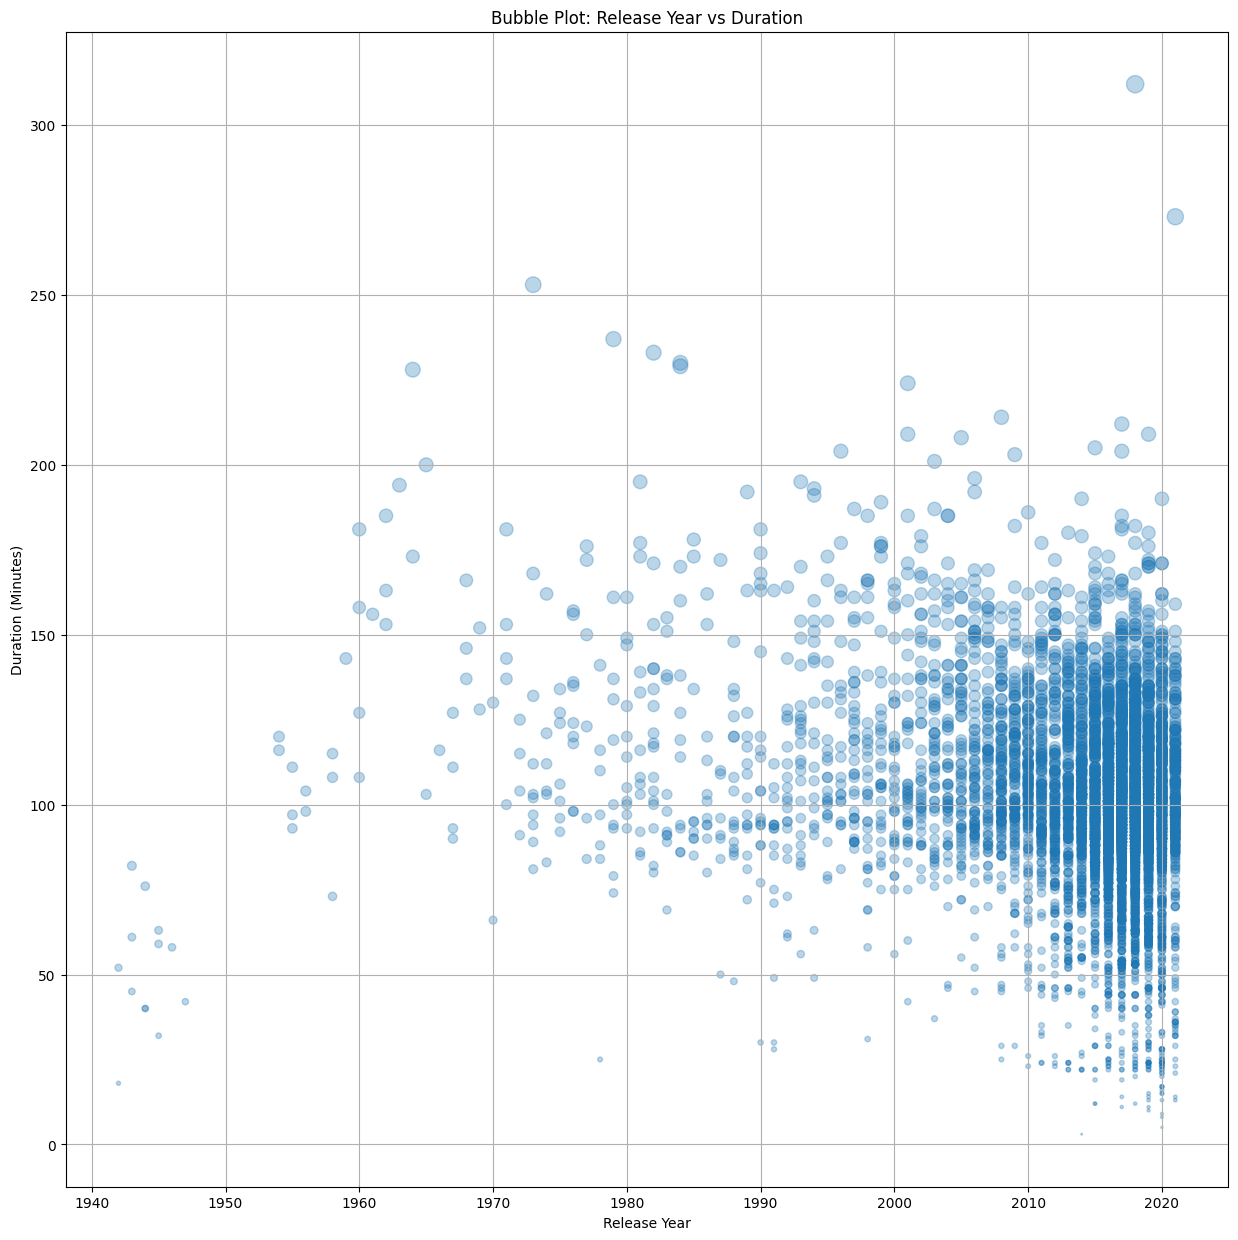

In [63]:
movie_df = df[df["type"]=="Movie"].copy()
movie_df = movie_df[movie_df["duration"]!="Unknown"]
movie_df["duration_num"] = movie_df["duration"].str.replace(" min","").astype(int)

plt.figure(figsize=(15,15))
plt.scatter(movie_df["release_year"],movie_df["duration_num"],s=movie_df["duration_num"]*0.5,alpha=0.3)

plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")
plt.title("Bubble Plot: Release Year vs Duration")
plt.grid()
plt.show()

### Step 4 Summary – Visualizations

1. A total of **8 visualizations** were created to better understand the Netflix dataset and identify important trends, patterns, and relationships within the data.

2. The **bar chart** showed the top countries contributing the highest number of Netflix titles, with the United States having the largest share.

3. The **line chart** and **histogram** were used to analyze release years and showed that the number of Netflix titles increased significantly in recent years.

4. The **scatter plot** and **bubble plot** were used to study the relationship between release year and movie duration, helping visualize the distribution of movie lengths across different years.

5. The **pie chart** displayed the distribution of Movies and TV Shows on Netflix, showing that Movies make up the majority of the content.

6. The **heatmap** helped identify the correlation between numeric variables, while the **boxplot** showed the distribution of release years and highlighted the presence of outliers.

7. Overall, the visualizations transformed the raw data into meaningful insights and made it easier to understand the structure and trends present in the Netflix dataset.




--------------------------------------------------------------------------------------------------------------------------------

 Step 5 – Insights Report

**1. Movies dominate the Netflix catalog.**:-
Based on the Pie Chart (Movies vs TV Shows Distribution), Movies account for approximately 69.6% of the content while TV Shows account for only 30.4%.
This indicates that Netflix focuses more on movie content than TV shows.

**2. The United States contributes the highest number of Netflix titles.**:-
From the Bar Chart showing the Top 10 Countries by Number of Netflix Titles, the United States has the highest number of titles, significantly exceeding other countries.
This suggests that Netflix content is heavily concentrated in the U.S. market.

**3. Netflix content has increased rapidly in recent years.**:-
The Line Chart and Histogram of Release Years show a sharp increase in the number of titles released after 2000, especially after 2010.
This indicates rapid growth in content production and acquisition.

**4. A large portion of Netflix titles were released after 2020.**:-
From the filtering analysis, 592 titles were released after 2020.
This shows that Netflix continues to add recent content to keep its library updated.

**5. Most Netflix content was released between 2013 and 2019.**:-
The Boxplot of Release Years shows that the majority of titles are concentrated within this period, while older titles appear as outliers.
This suggests that Netflix mainly focuses on relatively recent content.



Short Note:

The most surprising finding was that Netflix contains significantly more Movies than TV Shows, with Movies making up nearly 70% of the total content.

Another interesting observation was that the number of titles increased rapidly after 2010.

I was also surprised to see that the United States contributes far more Netflix titles than any other country in the dataset.

This shows how strongly Netflix content is concentrated in certain categories and regions.